In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
train = pd.read_csv(r"C:\Users\user\Desktop\New folder\statistics+ machine learning project\train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
test = pd.read_csv(r"C:\Users\user\Desktop\New folder\statistics+ machine learning project\test.csv")
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [35]:
train.info()
print("Train info:\n")

test.info()
print("Test info:\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Train info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  


In [21]:
print("\nMissing values in Train Dataset :\n")
print(train.isnull().sum())

print("\nMissing values in Test Dataset :\n")
print(test.isnull().sum())


Missing values in Train Dataset :

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values in Test Dataset :

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [23]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [37]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [39]:
train.loc[:, "Age"] = train["Age"].fillna(train["Age"].median())
test.loc[:, "Age"] = test["Age"].fillna(test["Age"].median())

In [41]:
train.loc[:, "Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])


In [45]:
test.loc[:, "Fare"] = test["Fare"].fillna(test["Fare"].median())

In [47]:
train.drop('Cabin', axis=1, inplace=True)
test.drop('Cabin', axis=1, inplace=True)

In [49]:
gender_survival = train.groupby("Sex")["Survived"].mean()
print(gender_survival)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


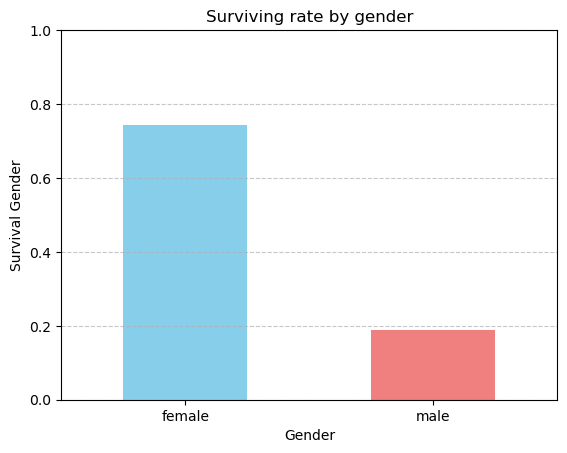

In [51]:
#Create a bar chart
gender_survival.plot(kind='bar', color=['skyblue', 'lightcoral'])

# Plotting the chart
plt.title("Surviving rate by gender")
plt.xlabel("Gender")
plt.ylabel("Survival Gender")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [53]:
Pclass_survived = train.groupby("Pclass")["Survived"].mean()
print(Pclass_survived)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


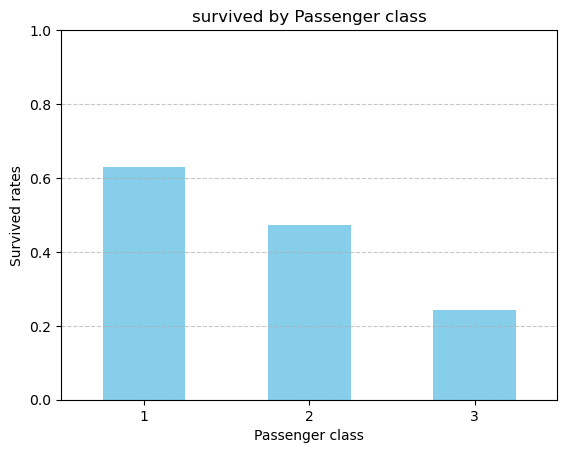

In [55]:
# Creating a bar chart
Pclass_survived.plot(kind='bar', color=['skyblue'])

#plot the chart
plt.title("survived by Passenger class")
plt.xlabel("Passenger class")
plt.ylabel("Survived rates")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [57]:
Embarked_survival = train.groupby('Embarked')['Survived'].mean()
print(Embarked_survival)

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


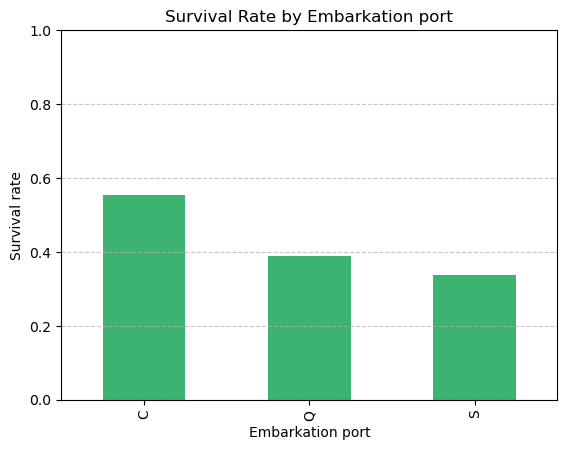

In [59]:
#Plotting the chart
Embarked_survival.plot(kind='bar', color=['mediumseagreen'])

#Bar chart
plt.title('Survival Rate by Embarkation port')
plt.xlabel('Embarkation port')
plt.ylabel('Survival rate')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [61]:
pd.crosstab(train['Embarked'], train['Pclass'], normalize='index') * 100

Pclass,1,2,3
Embarked,,,
C,50.595238,10.119048,39.285714
Q,2.597403,3.896104,93.506494
S,19.969040,25.386997,54.643963


In [63]:
children = [0, 12, 18, 35, 60, 100]
Sections = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

# Create a new Column in the dataframe
train['AgeGroup'] = pd.cut(train['Age'], bins=children, labels=Sections)

In [65]:
# Group by age group
age_survival = train.groupby('AgeGroup')['Survived'].mean()
print(age_survival)

AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_2672\1144715497.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = train.groupby('AgeGroup')['Survived'].mean()


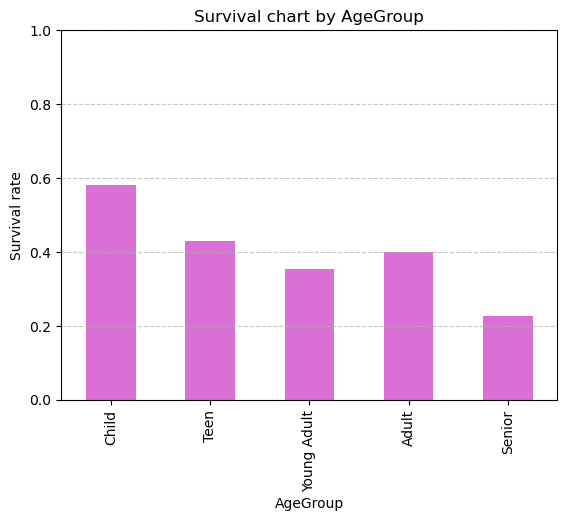

In [67]:
# Plotting the chart
age_survival.plot(kind='bar', color='orchid')

plt.title('Survival chart by AgeGroup')
plt.xlabel('AgeGroup')
plt.ylabel('Survival rate')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
          

In [69]:
# Grouping by 'Parch' to get survival rate
parch_survival = train.groupby('Parch')['Survived'].mean()
print(parch_survival)

Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64


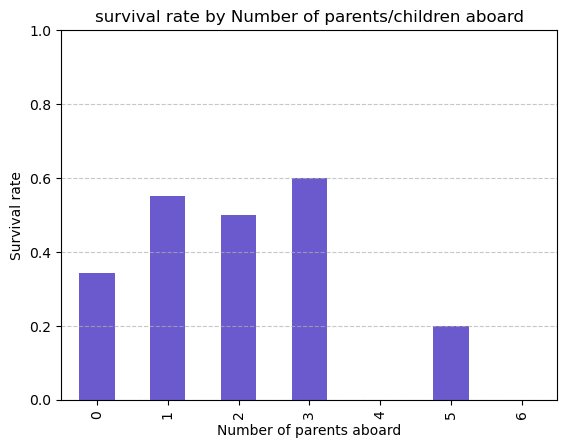

In [71]:
#Plotting the chart
parch_survival.plot(kind='bar', color= 'slateblue')

plt.title('survival rate by Number of parents/children aboard')
plt.xlabel('Number of parents aboard')
plt.ylabel('Survival rate')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [73]:
# Calculate IQR for Fare
Q1 = train['Fare'].quantile(0.25)
Q3 = train['Fare'].quantile(0.75)
IQR = Q3 - Q1

#Step-2
Lower_Bound = Q1 - 1.5 * IQR
Upper_Bound = Q3 + 1.5 * IQR

#Step 3
fare_outliers = train[(train['Fare'] < Lower_Bound) | (train['Fare'] > Upper_Bound)]
print(f"Number of outliers : {fare_outliers.shape[0]}")

Number of outliers : 116


In [75]:
low_outliers = train[train["Fare"] < Lower_Bound]
high_outliers = train[train["Fare"] > Upper_Bound]
print(len(low_outliers), "Low Outliers")
print(len(high_outliers), "high Outliers")

0 Low Outliers
116 high Outliers


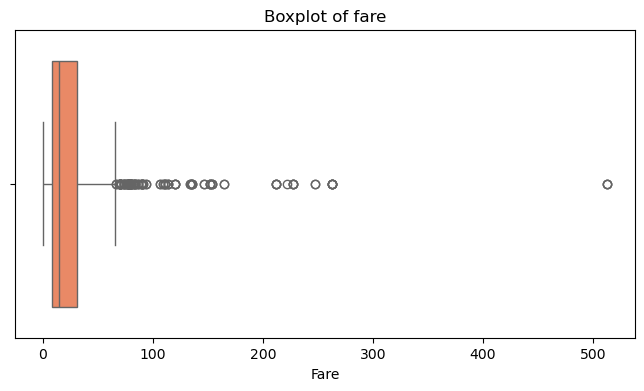

In [77]:
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(x=train['Fare'], color='coral')
plt.title('Boxplot of fare')
plt.xlabel('Fare')
plt.show()


In [79]:
train_ml = train.drop(columns=['Name', 'PassengerId', 'Ticket'])
print(train_ml)

     Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked  \
0           0       3    male  22.0      1      0   7.2500        S   
1           1       1  female  38.0      1      0  71.2833        C   
2           1       3  female  26.0      0      0   7.9250        S   
3           1       1  female  35.0      1      0  53.1000        S   
4           0       3    male  35.0      0      0   8.0500        S   
..        ...     ...     ...   ...    ...    ...      ...      ...   
886         0       2    male  27.0      0      0  13.0000        S   
887         1       1  female  19.0      0      0  30.0000        S   
888         0       3  female  28.0      1      2  23.4500        S   
889         1       1    male  26.0      0      0  30.0000        C   
890         0       3    male  32.0      0      0   7.7500        Q   

        AgeGroup  
0    Young Adult  
1          Adult  
2    Young Adult  
3    Young Adult  
4    Young Adult  
..           ...  
886  Young Adu

In [81]:
# Convert categorical variables to dummy variables
train_ml = pd.get_dummies(train_ml, columns=['Sex', 'Embarked'], drop_first=True)
print(train_ml)

     Survived  Pclass   Age  SibSp  Parch     Fare     AgeGroup  Sex_male  \
0           0       3  22.0      1      0   7.2500  Young Adult      True   
1           1       1  38.0      1      0  71.2833        Adult     False   
2           1       3  26.0      0      0   7.9250  Young Adult     False   
3           1       1  35.0      1      0  53.1000  Young Adult     False   
4           0       3  35.0      0      0   8.0500  Young Adult      True   
..        ...     ...   ...    ...    ...      ...          ...       ...   
886         0       2  27.0      0      0  13.0000  Young Adult      True   
887         1       1  19.0      0      0  30.0000  Young Adult     False   
888         0       3  28.0      1      2  23.4500  Young Adult     False   
889         1       1  26.0      0      0  30.0000  Young Adult      True   
890         0       3  32.0      0      0   7.7500  Young Adult      True   

     Embarked_Q  Embarked_S  
0         False        True  
1         False

In [83]:
train_ml = pd.get_dummies(train_ml, columns=['AgeGroup'], drop_first=True)

In [85]:
# define target and features
X = train_ml.drop('Survived', axis=1)
y = train_ml['Survived']

In [87]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [89]:
# Create a copy of test to work with
test_ml = test.copy()

train_ml['Age'] = train_ml['Age'].fillna(train_ml['Age'].median())
test_ml['Age'] = test_ml['Age'].fillna(test_ml['Age'].median())

train_ml['Fare'] = train_ml['Fare'].fillna(train_ml['Fare'].median())
test_ml['Fare'] = test_ml['Fare'].fillna(test_ml['Fare'].median())

In [91]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [128]:
print(train_ml.columns)

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'AgeGroup',
       'Sex_male', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [93]:
#make predictions
y_pred = model.predict(X_test)

In [95]:
#accuracy Score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.82


In [97]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[90 15]
 [18 56]]


In [12]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

def automate_titanic_model(file_path):
    #step 1 : Load Data
    data = pd.read_csv(file_path)

    #step 2 : Handle missing values
    data['Age'] = data['Age'].fillna(data['Age'].median())
    data['Fare'] = data['Fare'].fillna(data['Fare'].median())
    data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

    #step 3 : Encode categorical features
    data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)

    #step 4 : Drop columns not needed
    columns_to_drop = ['Name', 'Ticket', 'Cabin', 'Embarked']
    data = data.drop(columns=columns_to_drop, errors='ignore')

    #step 5 : Define Target and Features
    X = data.drop('Survived', axis=1)
    y = data['Survived']

    #step 6 : Train-Test-Split
    X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=42)

    #step 7 : Train Model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Step 8: Predict & evaluate
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print("✅ Model Accuracy:", round(acc * 100, 2), "%")
    print("🧩 Confusion Matrix:\n", cm)

    return model
   
model = automate_titanic_model(r"C:\Users\user\Desktop\New folder\statistics+ machine learning project\train.csv") #replace with your csv path 
    

✅ Model Accuracy: 79.78 %
🧩 Confusion Matrix:
 [[381  63]
 [ 81 187]]
